In [1]:
%pip install ultralytics
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from ultralytics import YOLO
import os
from IPython.display import Image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fatihkgg/affectnet-yolo-format")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format


In [3]:
train_images_path = os.path.join(path, 'YOLO_format', 'train', 'images')
image_files = os.listdir(train_images_path)

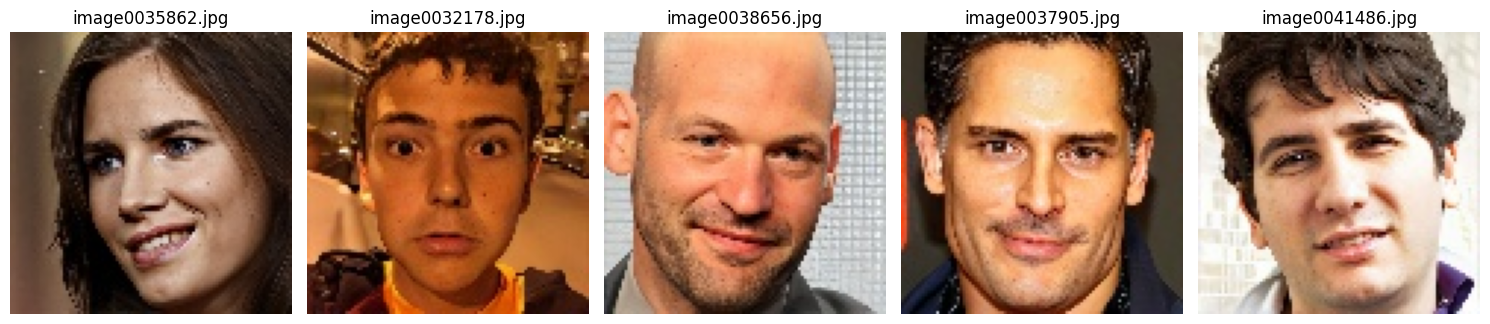

In [4]:
import random
import matplotlib.pyplot as plt
import cv2

random_images = random.sample(image_files, 5)
plt.figure(figsize=(15, 5))

for i, img_file in enumerate(random_images):
    img_path = os.path.join(train_images_path, img_file)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(img_file)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
yaml_content = """
path: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format
train: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/train
val: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/valid
test: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test

nc: 8
names: [ "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise",]
"""
with open("affectnet.yaml", "w") as f:
    f.write(yaml_content)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="affectnet.yaml",
    epochs=100,
    imgsz=704,
    batch=32,
    patience=20,

    # Save checkpoints
    save=True,
    save_period=10,

    # Color augmentations
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # Geometric augmentations
    degrees=10,
    translate=0.1,
    scale=0.3,
    shear=2.0,
    perspective=0.0001,

    # Flips
    fliplr=0.5,
    flipud=0.0,

    # Advanced augmentations
    mosaic=0.5,
    mixup=0.1,
    copy_paste=0.0,

    # Training settings
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    cos_lr=True,
    close_mosaic=10
)

In [6]:
from ultralytics import YOLO

model = YOLO("/kaggle/input/models/yuseifudo12/affectnet-yolov8m-emotion/pytorch/default/1/last.pt")

model.train(
    resume=True,
    amp=False,
    save=True,
    save_period=10
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=affectnet.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=704, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/kaggle/input/models/yuseifudo12/affectnet-yolov8m-emotion/pytorch/default/1/last.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, 

KeyboardInterrupt: 

In [8]:
from ultralytics import YOLO

# Load the best model from previous training
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

model.train(
    data="affectnet.yaml",

    # Fine-tuning settings
    epochs=10,
    imgsz=704,
    batch=32,
    patience=5,

    # Optimizer (much gentler)
    optimizer="AdamW",
    lr0=1e-5,
    lrf=0.001,
    weight_decay=0.0005,
    cos_lr=True,

    # Very light augmentations
    hsv_h=0.005,
    hsv_s=0.15,
    hsv_v=0.10,

    degrees=2,
    translate=0.02,
    scale=0.05,
    shear=0.5,
    perspective=0.0,

    # Flips
    fliplr=0.5,
    flipud=0.0,

    # Disable heavy augmentations
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,

    # Stability
    amp=False,

    # Save checkpoints
    save=True,
    save_period=10,
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=affectnet.yaml, degrees=2, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.005, hsv_s=0.15, hsv_v=0.1, imgsz=704, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/runs/detect/train/weights/best.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78671d0e8ce0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

### YOLOV8M (NORMAL) EVALUATION

In [9]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")
metrics = model.val(data="affectnet.yaml", split="val")

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 93 layers, 25,844,392 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 28.0±17.4 MB/s, size: 14.2 KB)
val: Scanning /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/valid/labels... 5406 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5406/5406 1.1Kit/s 4.9s0.1ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 338/338 2.0it/s 2:510.5ss
                   all       5406       5406      0.723      0.772      0.824      0.824
                 Anger        712        712      0.702      0.786      0.827      0.827
              Contempt        618        618      0.702      0.796      0.837      0.837
               Disgust        672

In [10]:
metrics = model.val(data="affectnet.yaml", split="test")

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1.7±1.2 MB/s, size: 8.6 KB)
val: Scanning /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test/labels... 2755 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2755/2755 286.2it/s 9.6s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 173/173 2.0it/s 1:280.5sss
                   all       2755       2755      0.729      0.768      0.822      0.822
                 Anger        383        383      0.724      0.778      0.831      0.831
              Contempt        332        332      0.716      0.767      0.811      0.811
               Disgust        327        327      0.721      0.716      0.794      0.794
                  Fear        


0: 704x704 1 Surprise, 30.8ms
Speed: 2.6ms preprocess, 30.8ms inference, 1.4ms postprocess per image at shape (1, 3, 704, 704)


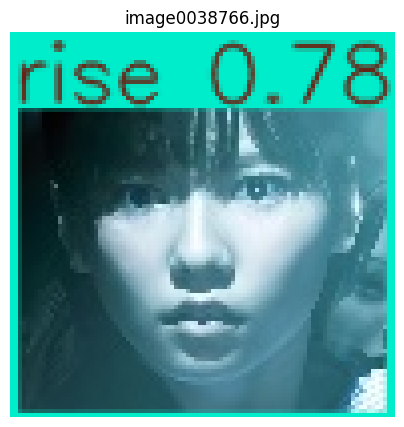


0: 704x704 1 Fear, 30.7ms
Speed: 2.4ms preprocess, 30.7ms inference, 1.3ms postprocess per image at shape (1, 3, 704, 704)


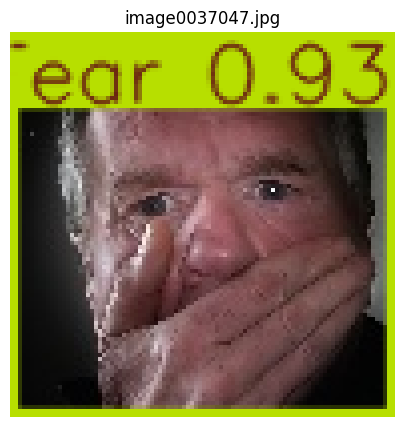


0: 704x704 1 Surprise, 30.8ms
Speed: 2.3ms preprocess, 30.8ms inference, 1.2ms postprocess per image at shape (1, 3, 704, 704)


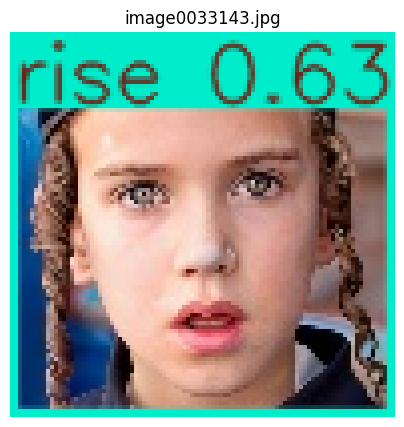


0: 704x704 1 Contempt, 30.8ms
Speed: 2.5ms preprocess, 30.8ms inference, 1.2ms postprocess per image at shape (1, 3, 704, 704)


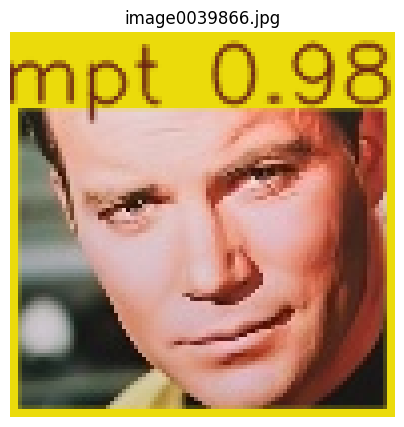


0: 704x704 1 Fear, 30.8ms
Speed: 2.6ms preprocess, 30.8ms inference, 1.3ms postprocess per image at shape (1, 3, 704, 704)


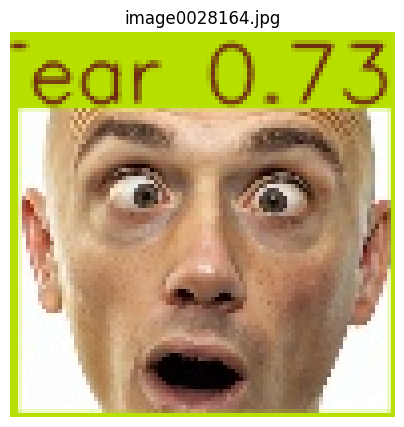

In [12]:
import random
import glob
import cv2
import matplotlib.pyplot as plt

test_images = glob.glob("/kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test/images/*.jpg")

samples = random.sample(test_images, 5)

for img_path in samples:
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(img_rgb)

    annotated = results[0].plot()

    plt.figure(figsize=(5,5))
    plt.imshow(annotated)
    plt.axis("off")
    plt.title(img_path.split("/")[-1])
    plt.show()


### YOLOV8M (FINE-TUNED) EVALUATION

In [13]:
from ultralytics import YOLO

model_1 = YOLO("/kaggle/working/runs/detect/train-3/weights/best.pt")
metrics = model_1.val(data="affectnet.yaml", split="val")

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 93 layers, 25,844,392 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10.4±10.3 MB/s, size: 10.5 KB)
val: Scanning /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/valid/labels... 5406 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5406/5406 1.1Kit/s 4.7s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 338/338 2.0it/s 2:520.5ss
                   all       5406       5406      0.719      0.775      0.822      0.822
                 Anger        712        712      0.685      0.788      0.824      0.824
              Contempt        618        618       0.71      0.801      0.842      0.842
               Disgust        672 

In [15]:
metrics = model_1.val(data="affectnet.yaml", split="test")

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 27.3±16.4 MB/s, size: 12.2 KB)
val: Scanning /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test/labels... 2755 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2755/2755 1.2Kit/s 2.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 173/173 2.0it/s 1:280.5sss
                   all       2755       2755      0.746      0.749      0.817      0.817
                 Anger        383        383      0.733      0.783      0.825      0.825
              Contempt        332        332      0.732      0.741      0.794      0.794
               Disgust        327        327      0.749      0.684      0.787      0.787
                  Fear      


0: 704x704 1 Surprise, 42.1ms
Speed: 3.9ms preprocess, 42.1ms inference, 1.3ms postprocess per image at shape (1, 3, 704, 704)


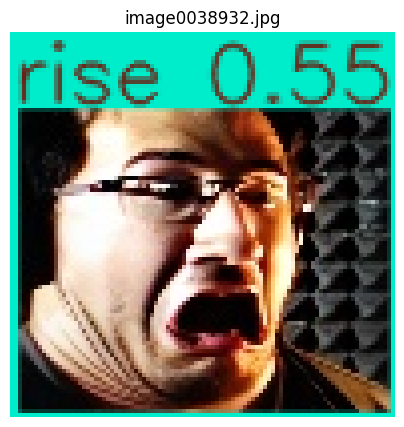


0: 704x704 1 Contempt, 41.2ms
Speed: 2.4ms preprocess, 41.2ms inference, 1.3ms postprocess per image at shape (1, 3, 704, 704)


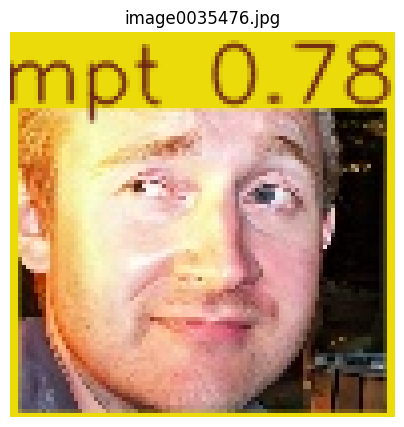


0: 704x704 1 Surprise, 31.2ms
Speed: 2.5ms preprocess, 31.2ms inference, 1.3ms postprocess per image at shape (1, 3, 704, 704)


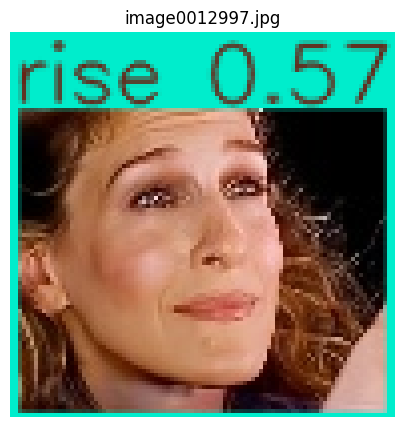


0: 704x704 1 Fear, 30.8ms
Speed: 2.2ms preprocess, 30.8ms inference, 1.3ms postprocess per image at shape (1, 3, 704, 704)


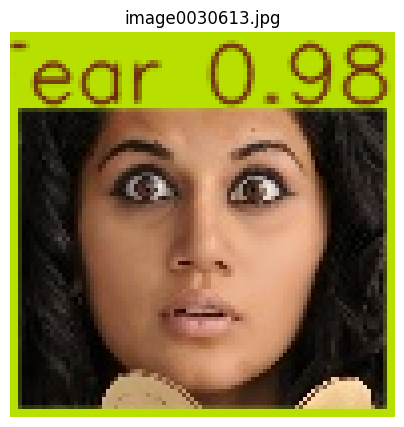


0: 704x704 1 Fear, 1 Surprise, 30.7ms
Speed: 2.3ms preprocess, 30.7ms inference, 1.2ms postprocess per image at shape (1, 3, 704, 704)


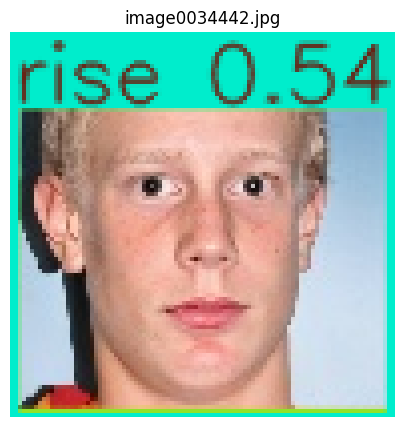

In [16]:
import random
import glob
import cv2
import matplotlib.pyplot as plt

test_images = glob.glob("/kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test/images/*.jpg")

samples = random.sample(test_images, 5)

for img_path in samples:
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model_1(img_rgb)

    annotated = results[0].plot()

    plt.figure(figsize=(5,5))
    plt.imshow(annotated)
    plt.axis("off")
    plt.title(img_path.split("/")[-1])
    plt.show()
